# Extracción de índices satelitales — Sentinel Hub

**Objetivo:** Cruzar las 100 parcelas del KML con imágenes Sentinel-2 para obtener series temporales de NDVI, EVI y NDMI (humedad).  
**Cuenta:** Evaluation (30,000 PU/mes)  
**Autenticación:** OAuth2 (client_id + client_secret)

---
## 0. Instalación y configuración

In [ ]:
# Ejecutar solo una vez
!pip install sentinelhub geopandas pandas numpy matplotlib python-dotenv tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
import os
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from tqdm.notebook import tqdm
from dotenv import load_dotenv

from sentinelhub import (
    SHConfig,
    BBox, CRS,
    DataCollection,
    SentinelHubRequest,
    SentinelHubStatistical,
    MimeType,
    bbox_to_dimensions,
    Geometry
)

load_dotenv()  # carga variables desde .env

# Montaje del Drive
from google.colab import drive
drive.mount('/content/drive')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('✓ Imports correctos')

Mounted at /content/drive
✓ Imports correctos


### 0.1 Configurar credenciales OAuth

In [ ]:
config = SHConfig()
config.sh_client_id     = '786a6cb9-7188-43d2-be17-275c26bf8c23'      # o pega directamente el valor aquí
config.sh_client_secret = 'FkfZcDwwZzYefE6QdKzys0g7JRDH9DpW'  # pero nunca subas esto a Git

# Verificar que las credenciales están cargadas
assert config.sh_client_id,     '⚠ SH_CLIENT_ID no encontrado — revisa tu archivo .env'
assert config.sh_client_secret, '⚠ SH_CLIENT_SECRET no encontrado — revisa tu archivo .env'

# Prueba de conexión rápida
from sentinelhub import SentinelHubSession
try:
    session = SentinelHubSession(config=config)
    _ = session.token
    print('✓ Conexión con Sentinel Hub exitosa')
except Exception as e:
    print(f'✗ Error de autenticación: {e}')

✓ Conexión con Sentinel Hub exitosa


---
## 1. Cargar parcelas

In [ ]:
# Cargar el GeoJSON procesado del notebook anterior
# Si no tienes el geojson, usa el KML directamente con la función de 01_EDA.ipynb
GEOJSON_PATH = '/content/drive/MyDrive/MNA/Avocados/processed/parcelas.geojson'

if Path(GEOJSON_PATH).exists():
    gdf = gpd.read_file(GEOJSON_PATH)
else:
    # Fallback: parsear el KML
    import xml.etree.ElementTree as ET
    from shapely.geometry import Point
    tree = ET.parse('/content/drive/MyDrive/MNA/Avocados/jalisco.kml')
    root = tree.getroot()
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name = pm.find('kml:name', ns).text
        lon, lat, _ = map(float, pm.find('.//kml:coordinates', ns).text.strip().split(','))
        records.append({'parcela': name, 'lon': lon, 'lat': lat, 'geometry': Point(lon, lat)})
    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')

print(f'✓ {len(gdf)} parcelas cargadas')
gdf[['parcela', 'lon', 'lat']].head()

✓ 100 parcelas cargadas


,parcela,lon,lat
0,H1,-103.487470,19.663164
1,H2,-103.491681,19.659585
2,H3,-103.495946,19.649232
3,H4,-103.493425,19.648928
4,H5,-103.490541,19.647687


---
## 2. Definir parámetros de extracción

In [ ]:
# ── Parámetros ajustables ──────────────────────────────────────────────────
BUFFER_DEG   = 0.0009    # ~100m radio alrededor de cada punto
RESOLUTION   = 10        # metros por pixel (Sentinel-2 banda 10m)
START_DATE   = '2023-01-01'
END_DATE     = '2024-12-31'
MAX_CC       = 20        # % máximo de nubosidad por escena
SLEEP_SEC    = 0.3       # pausa entre requests (rate limiting)
OUTPUT_DIR   = Path('/content/drive/MyDrive/MNA/Avocados/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────

print(f'Periodo: {START_DATE} → {END_DATE}')
print(f'Buffer:  {BUFFER_DEG}° ≈ {BUFFER_DEG * 111000:.0f} m')
print(f'Max nubosidad: {MAX_CC}%')

Periodo: 2023-01-01 → 2024-12-31
Buffer:  0.0009° ≈ 100 m
Max nubosidad: 20%


---
## 3. Evalscripts — NDVI, EVI, NDMI

In [ ]:
# Un solo evalscript que devuelve los 3 índices + máscara de nube (SCL)
# dataMask = 0 en píxeles nublados o sin dato → los marcamos como NaN

EVALSCRIPT = """
//VERSION=3
function setup() {
    return {
        input: [{
            bands: ["B04", "B08", "B02", "B11", "SCL", "dataMask"],
            units: "DN"
        }],
        output: {
            bands: 4,
            sampleType: "FLOAT32"
        }
    };
}

function evaluatePixel(s) {
    // SCL: 4=vegetation, 5=bare soil, 6=water, 8-10=cloud/shadow → enmascarar
    let validPixel = s.dataMask && (s.SCL == 4 || s.SCL == 5 || s.SCL == 6);
    let noData = -9999;

    if (!validPixel) return [noData, noData, noData, 0];

    let RED  = s.B04 / 10000;
    let NIR  = s.B08 / 10000;
    let BLUE = s.B02 / 10000;
    let SWIR = s.B11 / 10000;

    let NDVI = (NIR - RED) / (NIR + RED + 1e-10);
    let EVI  = 2.5 * (NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1);
    let NDMI = (NIR - SWIR) / (NIR + SWIR + 1e-10);  // índice humedad

    return [NDVI, EVI, NDMI, 1];
}
"""
print('✓ Evalscript definido (NDVI + EVI + NDMI)')

✓ Evalscript definido (NDVI + EVI + NDMI)


---
## 4. Función de extracción por parcela

In [ ]:
def get_indices_for_parcela(lon: float, lat: float, parcela_id: str,
                             start: str, end: str, config: SHConfig,
                             buffer: float = BUFFER_DEG,
                             resolution: int = RESOLUTION,
                             max_cc: int = MAX_CC) -> dict:
    """
    Extrae NDVI, EVI y NDMI promedio para una parcela en un rango de fechas.
    Retorna dict con las estadísticas o un registro de error.
    """
    bbox = BBox(
        bbox=[lon - buffer, lat - buffer, lon + buffer, lat + buffer],
        crs=CRS.WGS84
    )
    size = bbox_to_dimensions(bbox, resolution=resolution)

    request = SentinelHubRequest(
        evalscript=EVALSCRIPT,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=(start, end),
                mosaicking_order='leastCC',  # escoge la escena con menos nubes
                maxcc=max_cc / 100
            )
        ],
        responses=[
            SentinelHubRequest.output_response('default', MimeType.TIFF)
        ],
        bbox=bbox,
        size=size,
        config=config
    )

    data = request.get_data()[0]  # shape: (H, W, 4)
    mask = data[:, :, 3] == 1     # banda 4 = validez del pixel

    result = {'parcela': parcela_id, 'periodo': f'{start}/{end}',
              'pixels_validos': int(mask.sum()), 'pixels_total': int(mask.size)}

    if mask.sum() == 0:
        # Sin pixeles válidos (100% nublado en el periodo)
        result.update({'ndvi_mean': np.nan, 'ndvi_std': np.nan,
                        'evi_mean':  np.nan, 'evi_std':  np.nan,
                        'ndmi_mean': np.nan, 'ndmi_std': np.nan,
                        'cobertura_valida_pct': 0.0})
    else:
        for i, nombre in enumerate(['ndvi', 'evi', 'ndmi']):
            banda = data[:, :, i]
            valores = banda[mask]
            result[f'{nombre}_mean'] = float(np.nanmean(valores))
            result[f'{nombre}_std']  = float(np.nanstd(valores))
        result['cobertura_valida_pct'] = round(mask.sum() / mask.size * 100, 1)

    return result


# ── Prueba rápida con H1 ───────────────────────────────────────────────────
print('Probando con H1 (2024-01 a 2024-03)...')
h1 = gdf[gdf['parcela'] == 'H1'].iloc[0]
resultado_prueba = get_indices_for_parcela(
    h1.lon, h1.lat, 'H1',
    start='2024-01-01', end='2024-03-31',
    config=config
)
print(json.dumps(resultado_prueba, indent=2))

Probando con H1 (2024-01 a 2024-03)...
{
  "parcela": "H1",
  "periodo": "2024-01-01/2024-03-31",
  "pixels_validos": 380,
  "pixels_total": 380,
  "ndvi_mean": 0.20245987176895142,
  "ndvi_std": 0.07468178123235703,
  "evi_mean": 0.13209332525730133,
  "evi_std": 0.049173250794410706,
  "ndmi_mean": -0.09631269425153732,
  "ndmi_std": 0.09184333682060242,
  "cobertura_valida_pct": 100.0
}


---
## 5. Loop completo — serie temporal mensual para las 100 parcelas

> **Nota sobre Processing Units (PU):**  
> Cada request consume ~1–4 PU dependiendo del tamaño del bbox.  
> Con 100 parcelas × 24 meses = 2,400 requests ≈ 5,000–10,000 PU.  
> El plan Evaluation tiene 30,000 PU/mes — alcanza de sobra.

In [ ]:
def generar_meses(start: str, end: str):
    """Genera lista de (inicio_mes, fin_mes) entre start y end."""
    inicio = datetime.strptime(start, '%Y-%m-%d')
    fin    = datetime.strptime(end,   '%Y-%m-%d')
    meses = []
    actual = inicio.replace(day=1)
    while actual <= fin:
        if actual.month == 12:
            siguiente = actual.replace(year=actual.year+1, month=1)
        else:
            siguiente = actual.replace(month=actual.month+1)
        fin_mes = min(siguiente - timedelta(days=1), fin)
        meses.append((actual.strftime('%Y-%m-%d'), fin_mes.strftime('%Y-%m-%d')))
        actual = siguiente
    return meses

meses = generar_meses(START_DATE, END_DATE)
print(f'Periodos a procesar: {len(meses)} meses')
print(f'Total requests: {len(gdf) * len(meses):,} ({len(gdf)} parcelas × {len(meses)} meses)')

Periodos a procesar: 24 meses
Total requests: 2,400 (100 parcelas × 24 meses)


In [ ]:
# ── Loop principal ─────────────────────────────────────────────────────────
# Soporta reanudación: si el CSV ya existe, carga lo procesado y continúa.

OUTPUT_CSV = OUTPUT_DIR / 'indices_satelitales.csv'

if OUTPUT_CSV.exists():
    df_existing = pd.read_csv(OUTPUT_CSV)
    done_keys = set(zip(df_existing['parcela'], df_existing['periodo']))
    resultados = df_existing.to_dict('records')
    print(f'Reanudando: {len(done_keys)} requests ya completados')
else:
    done_keys = set()
    resultados = []

errores = []

for _, row in tqdm(gdf.iterrows(), total=len(gdf), desc='Parcelas'):
    for mes_ini, mes_fin in meses:
        key = (row['parcela'], f'{mes_ini}/{mes_fin}')
        if key in done_keys:
            continue  # ya procesado

        try:
            res = get_indices_for_parcela(
                row['lon'], row['lat'], row['parcela'],
                start=mes_ini, end=mes_fin, config=config
            )
            resultados.append(res)
            time.sleep(SLEEP_SEC)

        except Exception as e:
            errores.append({'parcela': row['parcela'], 'periodo': key[1], 'error': str(e)})
            print(f'  ⚠ Error en {row["parcela"]} {mes_ini}: {e}')

    # Guardar checkpoint cada parcela completa
    pd.DataFrame(resultados).to_csv(OUTPUT_CSV, index=False)

df = pd.DataFrame(resultados)
print(f'\n✓ Extracción completa: {len(df)} registros')
print(f'  Errores: {len(errores)}')
if errores:
    pd.DataFrame(errores).to_csv(OUTPUT_DIR / 'errores_extraccion.csv', index=False)
df.head()

Reanudando: 864 requests ya completados


Parcelas:   0%|          | 0/100 [00:00<?, ?it/s]


✓ Extracción completa: 2400 registros
  Errores: 0


,parcela,periodo,pixels_validos,pixels_total,ndvi_mean,ndvi_std,evi_mean,evi_std,ndmi_mean,ndmi_std,cobertura_valida_pct
0,H1,2023-01-01/2023-01-31,380,380,0.357744,0.161140,0.199538,0.086246,-0.042727,0.091699,100.0
1,H1,2023-02-01/2023-02-28,380,380,0.267209,0.109666,0.150785,0.059053,-0.114700,0.092479,100.0
2,H1,2023-03-01/2023-03-31,380,380,0.211122,0.076697,0.130898,0.044161,-0.145487,0.094168,100.0
3,H1,2023-04-01/2023-04-30,380,380,0.213040,0.078446,0.133167,0.046257,-0.133828,0.100172,100.0
4,H1,2023-05-01/2023-05-31,380,380,0.221562,0.096237,0.137895,0.064462,-0.157839,0.096763,100.0


---
## 6. Preprocesamiento de la serie temporal

In [ ]:
# Cargar resultado (o continuar desde df si ya está en memoria)
df = pd.read_csv(OUTPUT_DIR / 'indices_satelitales.csv')

# Parsear fecha de inicio del periodo
df['fecha'] = pd.to_datetime(df['periodo'].str.split('/').str[0])
df['mes']   = df['fecha'].dt.month
df['año']   = df['fecha'].dt.year

print('=== Estructura del dataset ===')
print(df.shape)
print(df.dtypes)
print()
print('=== Valores faltantes (NaN = nubosidad) ===')
faltantes = df[['ndvi_mean','evi_mean','ndmi_mean']].isnull().sum()
print(faltantes)
print(f'\nPorcentaje de nubosidad: {faltantes["ndvi_mean"] / len(df) * 100:.1f}%')

=== Estructura del dataset ===
(2400, 14)
parcela                         object
periodo                         object
pixels_validos                   int64
pixels_total                     int64
ndvi_mean                      float64
ndvi_std                       float64
evi_mean                       float64
evi_std                        float64
ndmi_mean                      float64
ndmi_std                       float64
cobertura_valida_pct           float64
fecha                   datetime64[ns]
mes                              int32
año                              int32
dtype: object

=== Valores faltantes (NaN = nubosidad) ===
ndvi_mean    151
evi_mean     151
ndmi_mean    151
dtype: int64

Porcentaje de nubosidad: 6.3%


In [ ]:
# Estrategia de imputación:
# 1. Interpolación lineal temporal por parcela (primera opción)
# 2. Si quedan NaN al inicio/fin de serie → rellenar con mediana del mes en todas las parcelas

df = df.sort_values(['parcela', 'fecha'])

for idx in ['ndvi_mean', 'evi_mean', 'ndmi_mean']:
    # Paso 1: interpolación lineal dentro de cada parcela
    df[idx] = df.groupby('parcela')[idx].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both')
    )
    # Paso 2: imputar con mediana mensual global si siguen faltando
    mediana_mensual = df.groupby('mes')[idx].transform('median')
    df[idx] = df[idx].fillna(mediana_mensual)

nan_restantes = df[['ndvi_mean','evi_mean','ndmi_mean']].isnull().sum().sum()
print(f'NaN tras imputación: {nan_restantes}')
df.to_csv(OUTPUT_DIR / 'indices_imputados.csv', index=False)
print('✓ Guardado → indices_imputados.csv')

NaN tras imputación: 0
✓ Guardado → indices_imputados.csv


---
## 7. Visualizaciones EDA satelital

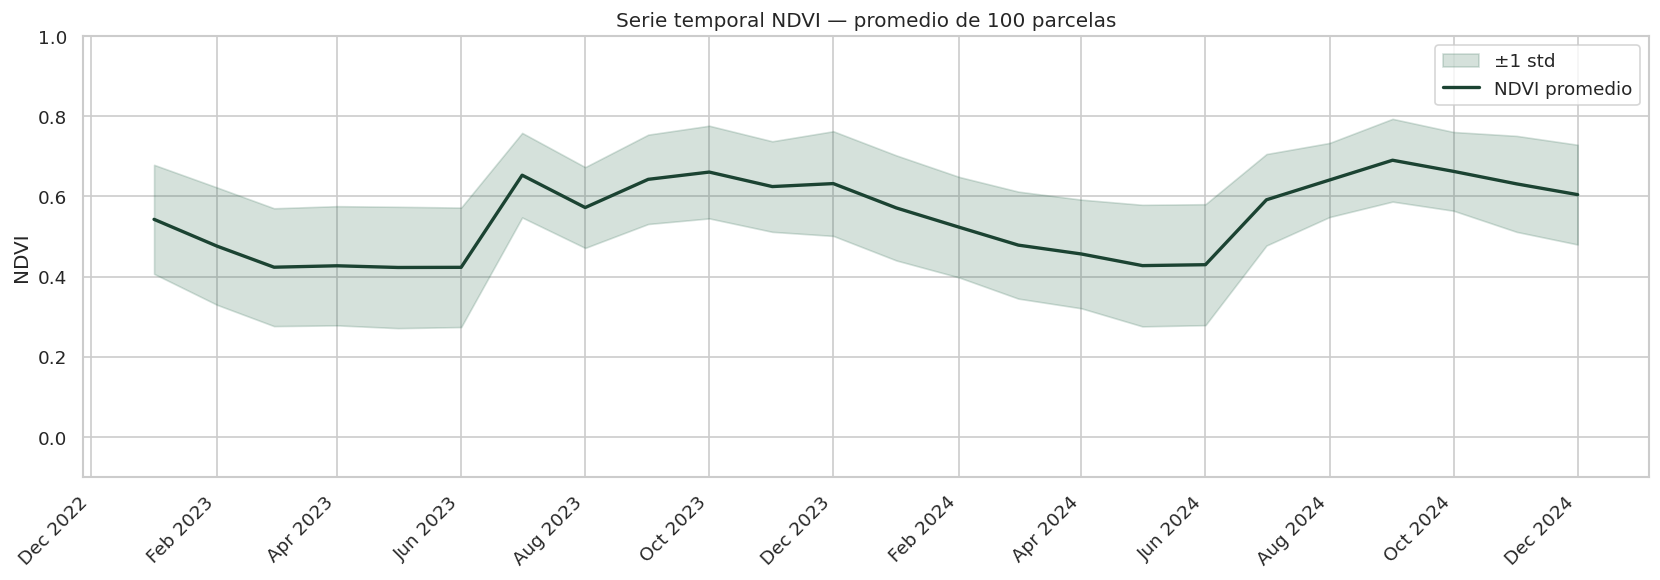

In [ ]:
# 7.1 Serie temporal promedio de NDVI (todas las parcelas)
ndvi_global = df.groupby('fecha')['ndvi_mean'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(ndvi_global['fecha'],
                ndvi_global['mean'] - ndvi_global['std'],
                ndvi_global['mean'] + ndvi_global['std'],
                alpha=0.2, color='#2d6a4f', label='±1 std')
ax.plot(ndvi_global['fecha'], ndvi_global['mean'],
        color='#1b4332', linewidth=2, label='NDVI promedio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('NDVI')
ax.set_title('Serie temporal NDVI — promedio de 100 parcelas')
ax.legend()
ax.set_ylim(-0.1, 1.0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/06_serie_ndvi_global.png', bbox_inches='tight')
plt.show()

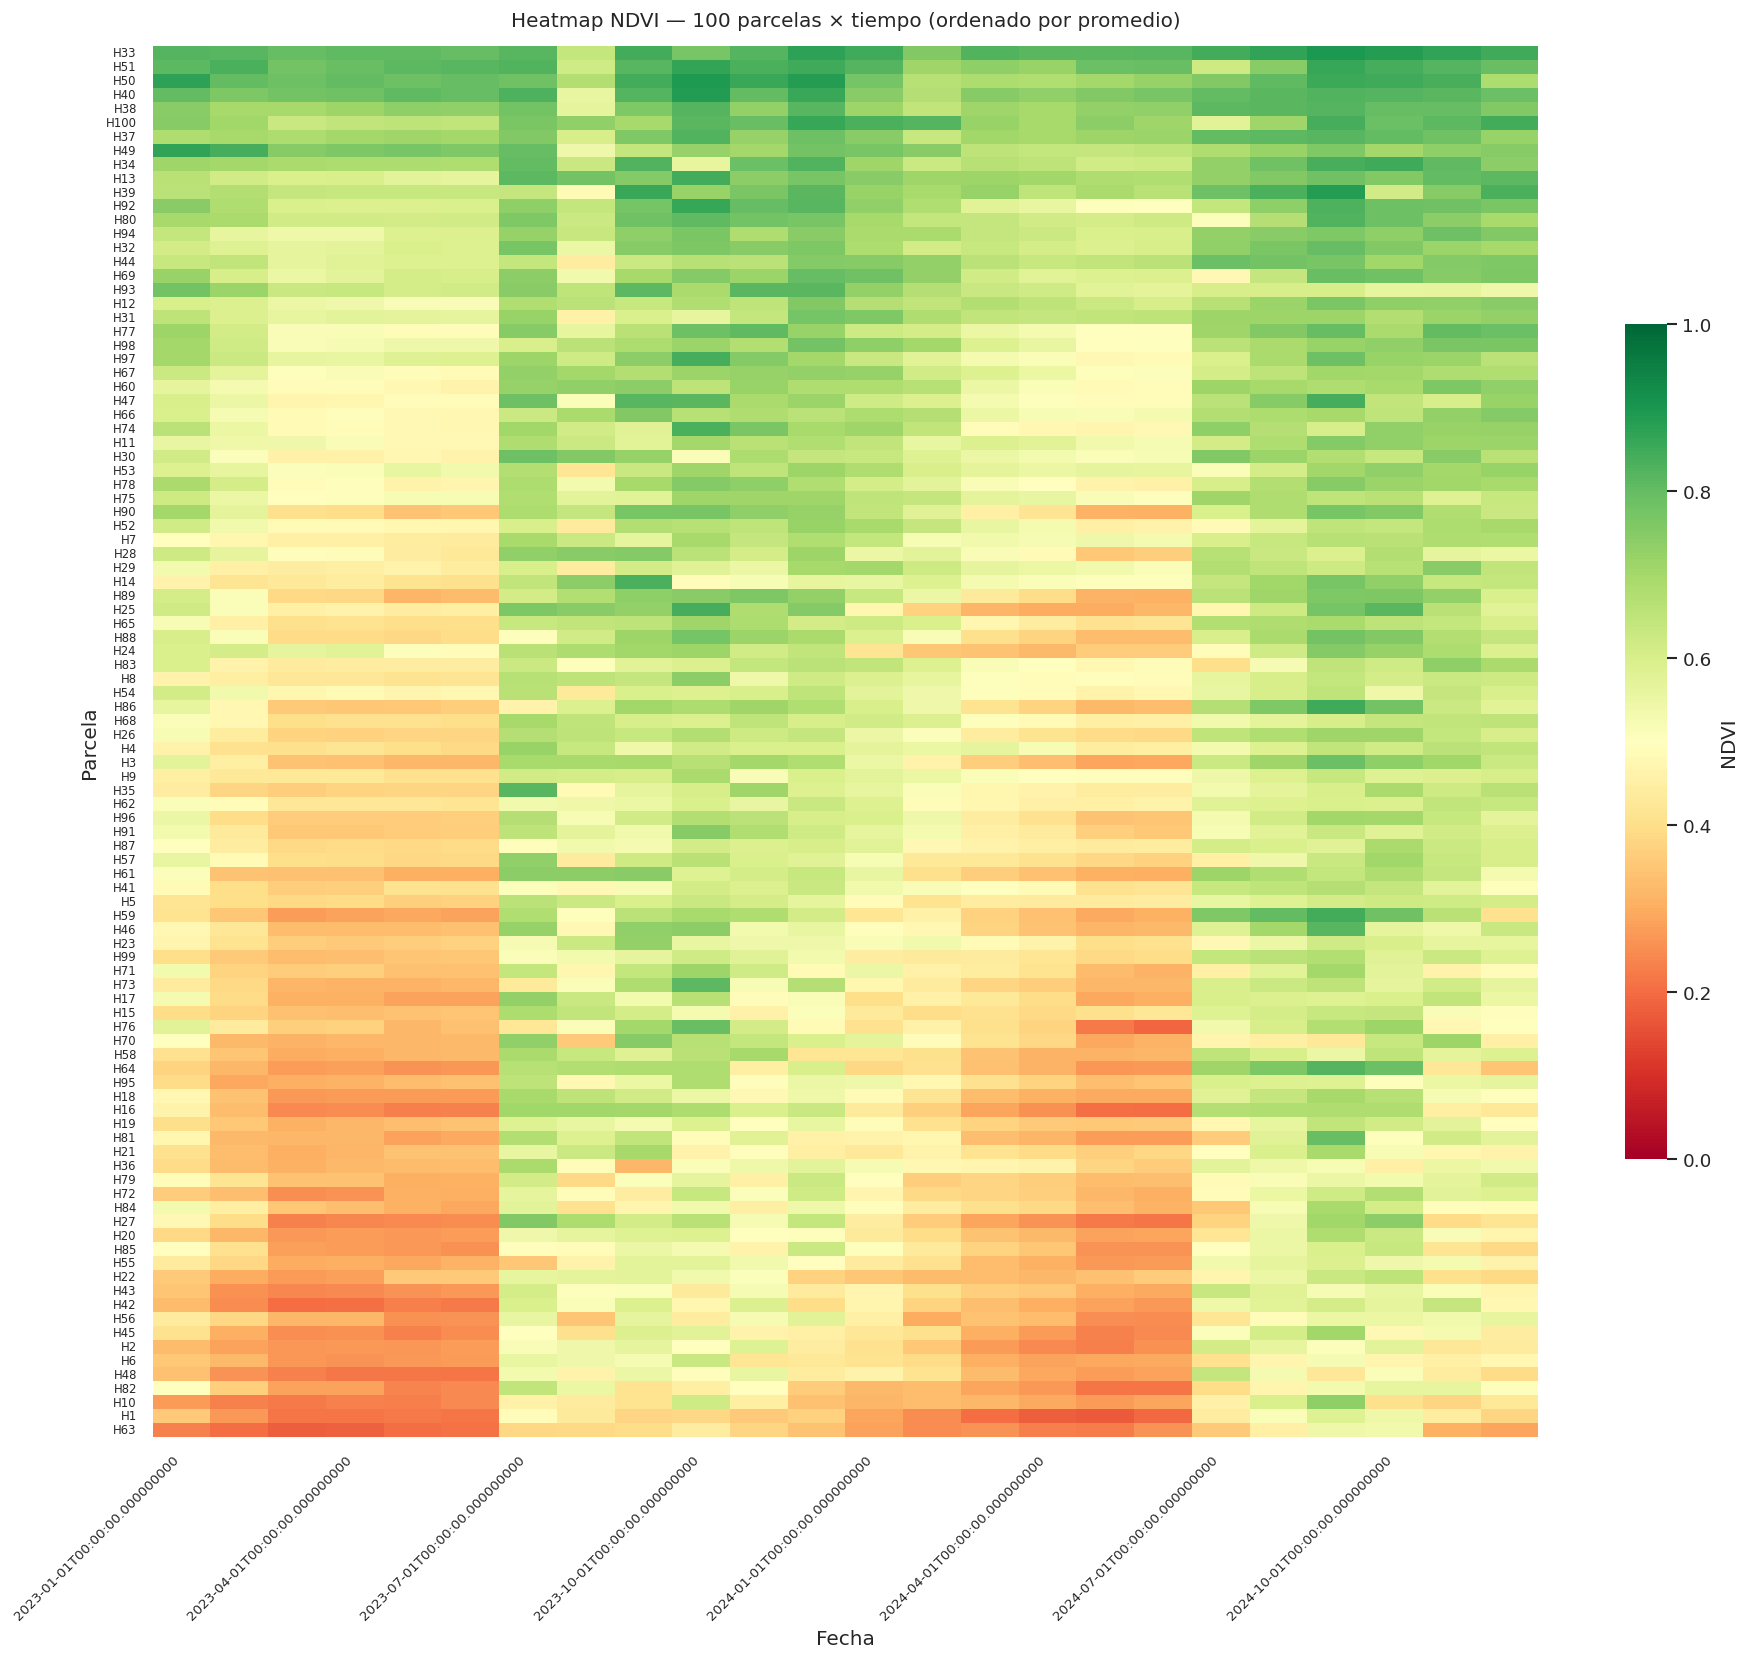

In [ ]:
# 7.2 Heatmap NDVI por parcela × mes
pivot = df.pivot_table(index='parcela', columns='fecha', values='ndvi_mean')
# Ordenar parcelas por NDVI promedio
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(pivot, cmap='RdYlGn', center=0.5, vmin=0, vmax=1,
            ax=ax, cbar_kws={'label': 'NDVI', 'shrink': 0.6},
            xticklabels=3, yticklabels=True)
ax.set_title('Heatmap NDVI — 100 parcelas × tiempo (ordenado por promedio)', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Parcela')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/07_heatmap_ndvi.png', bbox_inches='tight')
plt.show()

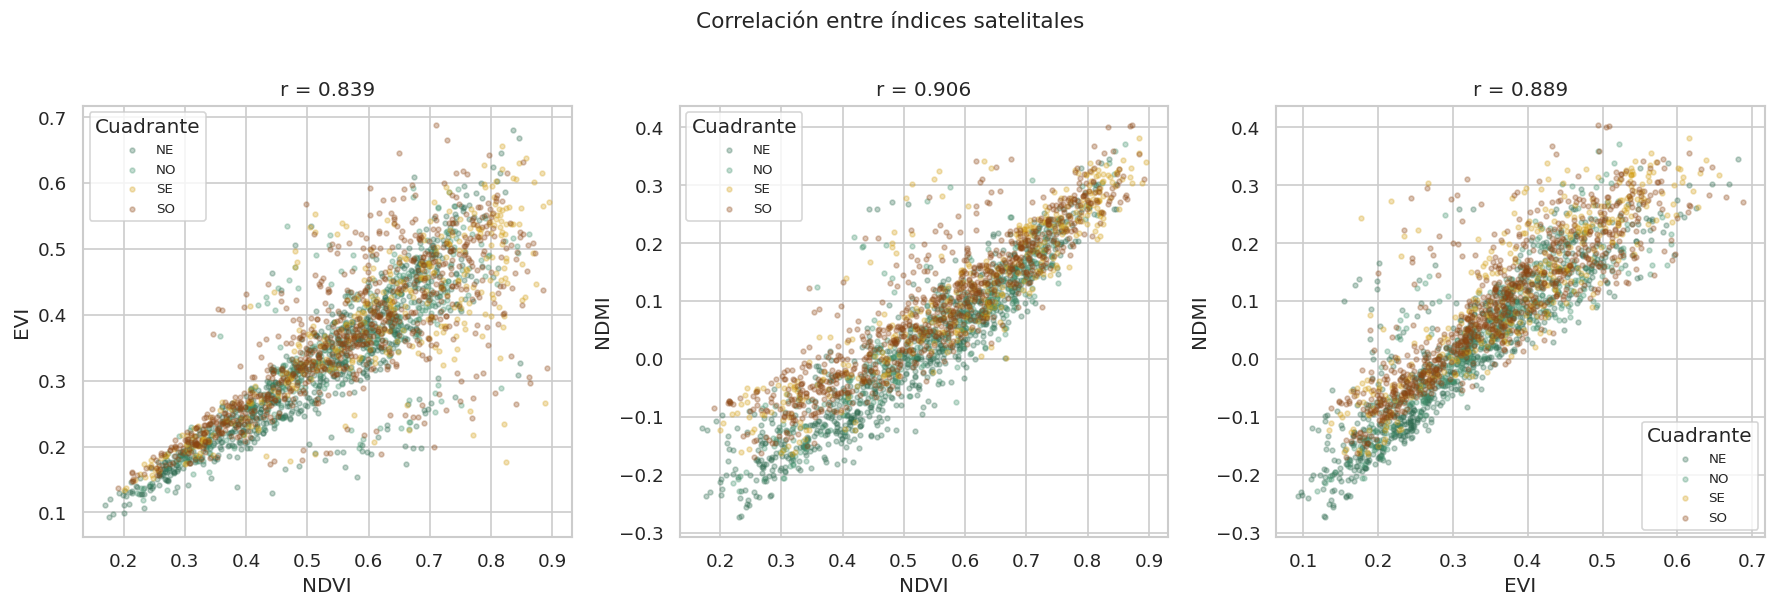

In [ ]:
# 7.3 Correlación entre índices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pares = [('ndvi_mean','evi_mean'), ('ndvi_mean','ndmi_mean'), ('evi_mean','ndmi_mean')]
colores_quad = {'NE':'#2d6a4f','NO':'#40916c','SE':'#d4a017','SO':'#8B4513'}

# Unir cuadrante si está disponible
if 'cuadrante' in gdf.columns:
    df = df.merge(gdf[['parcela','cuadrante']], on='parcela', how='left')

for ax, (x, y) in zip(axes, pares):
    if 'cuadrante' in df.columns:
        for quad, grupo in df.groupby('cuadrante'):
            ax.scatter(grupo[x], grupo[y], alpha=0.3, s=8,
                       label=quad, color=colores_quad.get(quad, 'gray'))
        ax.legend(fontsize=8, title='Cuadrante')
    else:
        ax.scatter(df[x], df[y], alpha=0.3, s=8, color='#2d6a4f')
    corr_val = df[[x, y]].corr().iloc[0,1]
    ax.set_xlabel(x.replace('_mean','').upper())
    ax.set_ylabel(y.replace('_mean','').upper())
    ax.set_title(f'r = {corr_val:.3f}')

fig.suptitle('Correlación entre índices satelitales', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/08_correlacion_indices.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1979/1011935261.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='mes_nombre', y='ndvi_mean',


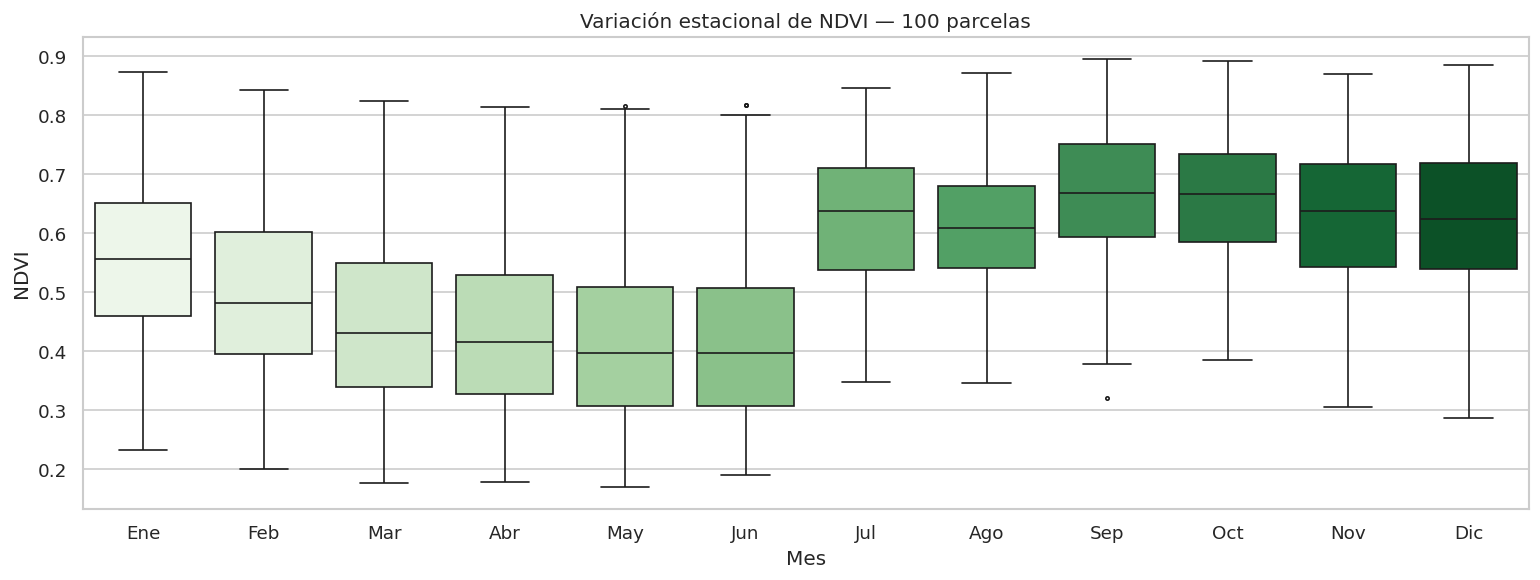


Mediana NDVI por mes:
mes
1     0.557
2     0.482
3     0.431
4     0.415
5     0.396
6     0.396
7     0.637
8     0.609
9     0.669
10    0.666
11    0.638
12    0.624
Name: ndvi_mean, dtype: float64


In [ ]:
# 7.4 Boxplot mensual de NDVI — patrón estacional
nombres_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
df['mes_nombre'] = df['mes'].apply(lambda m: nombres_mes[m-1])

fig, ax = plt.subplots(figsize=(13, 5))
df_sorted = df.copy()
df_sorted['mes_nombre'] = pd.Categorical(df_sorted['mes_nombre'], categories=nombres_mes, ordered=True)
df_sorted = df_sorted.sort_values('mes_nombre')

sns.boxplot(data=df_sorted, x='mes_nombre', y='ndvi_mean',
            palette='Greens', ax=ax, fliersize=2)
ax.set_xlabel('Mes')
ax.set_ylabel('NDVI')
ax.set_title('Variación estacional de NDVI — 100 parcelas')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/09_estacionalidad_ndvi.png', bbox_inches='tight')
plt.show()

print('\nMediana NDVI por mes:')
print(df.groupby('mes')['ndvi_mean'].median().round(3))

Parcelas atípicas por NDVI promedio: 0


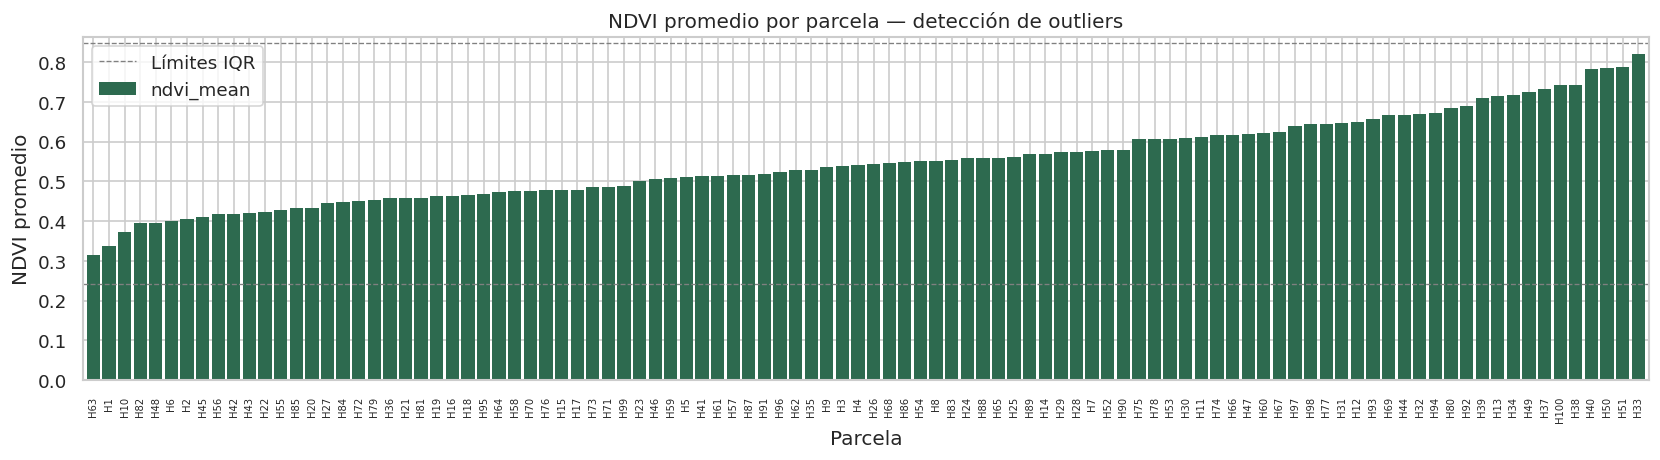

In [ ]:
# 7.5 Detección de parcelas atípicas (NDVI promedio fuera del IQR)
ndvi_por_parcela = df.groupby('parcela')['ndvi_mean'].mean()
Q1, Q3 = ndvi_por_parcela.quantile(0.25), ndvi_por_parcela.quantile(0.75)
IQR = Q3 - Q1
outliers = ndvi_por_parcela[(ndvi_por_parcela < Q1 - 1.5*IQR) | (ndvi_por_parcela > Q3 + 1.5*IQR)]

print(f'Parcelas atípicas por NDVI promedio: {len(outliers)}')
if len(outliers) > 0:
    print(outliers.sort_values())

fig, ax = plt.subplots(figsize=(14, 4))
ndvi_por_parcela.sort_values().plot(kind='bar', ax=ax,
    color=['#e63946' if p in outliers.index else '#2d6a4f' for p in ndvi_por_parcela.sort_values().index],
    edgecolor='none', width=0.85)
ax.axhline(Q1 - 1.5*IQR, color='gray', linestyle='--', linewidth=0.8, label='Límites IQR')
ax.axhline(Q3 + 1.5*IQR, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Parcela')
ax.set_ylabel('NDVI promedio')
ax.set_title('NDVI promedio por parcela — detección de outliers')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/10_outliers_ndvi.png', bbox_inches='tight')
plt.show()

---
## 8. Conclusiones del EDA satelital

*(Completa esta sección con los hallazgos reales una vez que tengas los datos)*

1. **Valores faltantes:** X% de las observaciones presentan NaN por cobertura de nubes, concentrados en los meses de [temporada de lluvias]. Se aplicó interpolación lineal temporal seguida de imputación por mediana mensual.

2. **Estacionalidad:** Se observa un patrón estacional claro en NDVI, con pico en [meses] coincidiendo con la temporada de lluvias y valores mínimos en [meses].

3. **Outliers:** [N] parcelas presentan NDVI atípico (H_X, H_Y…) — posibles candidatas a revisión de campo o exclusión del modelo.

4. **Correlación entre índices:** NDVI y EVI presentan correlación r=[valor], lo que sugiere [conclusión]. NDMI aporta información complementaria sobre el estado hídrico.

5. **Variable objetivo:** [Aquí irá la variable target una vez definida — rendimiento, presencia de plaga, etc.]
